<a href="https://colab.research.google.com/github/soyeon24/ECE2Finalproject/blob/main/eye2sky_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eye2Sky GHI 예측 (수정판)

**주요 수정사항:**
1. OLCLO 이미지 + OLCLO 광량 (자가일관성)
2. Target = KT (clear-sky index), cGHI를 input에서 제거
3. 30초 → 5분 간격 subsample
4. Random split → 날짜 단위 split (test leakage 차단)
5. 기간 5일 → 30일

**실행 순서:** 셀을 위에서 아래로 순서대로 실행. `OLCLO_cleaned.nc` 파일을 첫 셀에서 업로드해야 함.

## 1. 환경 세팅 + OLCLO_cleaned.nc 업로드

In [2]:
!pip install -q netCDF4 xarray

# OLCLO_cleaned.nc 업로드
from google.colab import files
print('OLCLO_cleaned.nc 파일을 선택하세요')
uploaded = files.upload()

OLCLO_cleaned.nc 파일을 선택하세요


Saving OLCLO.cleaned.nc to OLCLO.cleaned.nc


## 2. 광량 데이터 로드 + KT 계산

In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import os

# 업로드된 파일명 자동 감지 (OLCLO_cleaned.nc 또는 OLCLO.cleaned.nc 둘 다 대응)
nc_file = None
for f in os.listdir('.'):
    if 'OLCLO' in f and f.endswith('.nc'):
        nc_file = f
        break
assert nc_file is not None, 'OLCLO .nc 파일이 없음. 다시 업로드 필요.'
print(f'로드: {nc_file}')

ds = xr.open_dataset(nc_file)
print('\n=== Dataset 구조 ===')
print(ds)
print('\n=== 변수 목록 ===')
print(list(ds.data_vars))

로드: OLCLO.cleaned.nc

=== Dataset 구조 ===
<xarray.Dataset> Size: 55MB
Dimensions:       (time: 525600)
Coordinates:
  * time          (time) datetime64[ns] 4MB 2022-04-01T00:01:00 ... 2023-04-01
    latitude      float64 8B ...
    longitude     float64 8B ...
    elevation     int64 8B ...
Data variables: (12/14)
    GTI_30_180    (time) float64 4MB ...
    cDNI          (time) float64 4MB ...
    RH            (time) float64 4MB ...
    cGHI          (time) float64 4MB ...
    turbidity     (time) float64 4MB ...
    SAZ           (time) float64 4MB ...
    ...            ...
    T             (time) float64 4MB ...
    DHI           (time) float64 4MB ...
    cDHI          (time) float64 4MB ...
    SZA           (time) float64 4MB ...
    station_name  <U5 20B ...
    crs           int64 8B ...
Attributes: (12/36)
    grid_mapping_name:            latitude_longitude
    longitude_of_prime_meridian:  0.0
    semi_major_axis:              6378137.0
    inverse_flattening:           29

In [4]:
# 필요한 변수만 추출. 변수명이 다르면 위 출력 보고 수정.
df = ds[['GHI', 'cGHI', 'DHI', 'SZA']].to_dataframe()
print(f'전체 데이터: {len(df):,}개')
print(f'기간: {df.index.min()} ~ {df.index.max()}')
print(f'결측치:\n{df.isnull().sum()}')

# 주간 + GHI 음수 제거
df_day = df[(df['SZA'] < 85) & (df['GHI'] >= 0)].copy()

# Clear-sky Index (KT) = GHI / cGHI - 이게 새 target
df_day['KT'] = df_day['GHI'] / df_day['cGHI'].replace(0, np.nan)
df_day['KT'] = df_day['KT'].clip(0, 1.5)
df_day = df_day.dropna(subset=['KT'])

print(f'\n주간 필터 후: {len(df_day):,}개')
print(df_day[['GHI', 'cGHI', 'KT', 'SZA']].describe())

전체 데이터: 525,600개
기간: 2022-04-01 00:01:00 ~ 2023-04-01 00:00:00
결측치:
GHI          1937
cGHI            0
DHI          1953
SZA             0
latitude        0
longitude       0
elevation       0
dtype: int64

주간 필터 후: 235,025개
                 GHI           cGHI             KT            SZA
count  235025.000000  235025.000000  235025.000000  235025.000000
mean      274.243264     400.498606       0.663952      62.790510
std       236.074916     237.817195       0.366706      15.259476
min         0.000000      47.272761       0.000000      29.656482
25%        82.400000     193.774554       0.337441      50.935435
50%       198.600000     363.791232       0.610361      65.610229
75%       410.800000     600.426105       1.013354      76.024713
max      1235.100000     862.254948       1.500000      84.999900


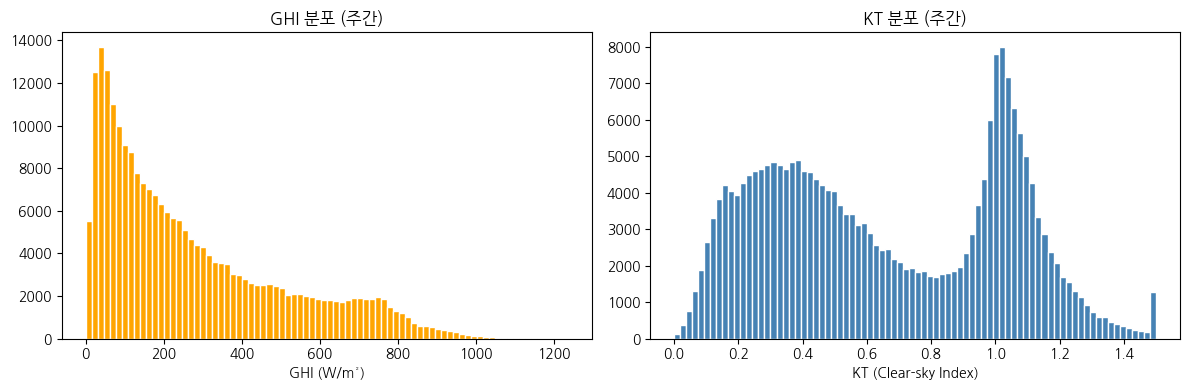

In [5]:
# 한글 폰트 설치 (시각화용)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_day['GHI'], bins=80, color='orange', edgecolor='white')
axes[0].set_xlabel('GHI (W/m²)')
axes[0].set_title('GHI 분포 (주간)')
axes[1].hist(df_day['KT'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_xlabel('KT (Clear-sky Index)')
axes[1].set_title('KT 분포 (주간)')
plt.tight_layout()
plt.show()

## 3. OLCLO 이미지 다운로드

**주의:** 30일치 다운로드. 약 1GB, 시간은 10~30분 정도. 디스크 부족하면 `END_DATE`를 줄여라.

In [9]:
import urllib.request, warnings
from datetime import datetime, timedelta

START_DATE = '2022-04-01'
END_DATE   = '2022-04-30'   # 디스크/시간 부족하면 줄이기
SITE       = 'OLCLO'        # OLCLO 단일 관측소

URL_TPL = 'https://eye2sky.de/data/asi/imgs/{dt:%Y/%m/%d}/ASI_{dt:%Y%m%d}_{stn}.zip'
LOCAL_TPL = os.path.join('Eye2Sky', '{dt:%Y/%m/%d}', 'ASI_{dt:%Y%m%d}_{stn}.zip')

start = datetime.strptime(START_DATE, '%Y-%m-%d')
end   = datetime.strptime(END_DATE,   '%Y-%m-%d')
dates = [start + timedelta(days=x) for x in range((end-start).days + 1)]

print(f'총 {len(dates)}일치 다운로드 시작')
ok, skip, fail = 0, 0, 0
for dt in dates:
    url = URL_TPL.format(stn=SITE, dt=dt)
    fname = LOCAL_TPL.format(stn=SITE, dt=dt)
    if os.path.exists(fname):
        skip += 1
        continue
    os.makedirs(os.path.dirname(fname), exist_ok=True)
    try:
        urllib.request.urlretrieve(url, fname)
        ok += 1
        print(f'  ✓ {dt:%Y-%m-%d}')
    except Exception as e:
        fail += 1
        print(f'  ✗ {dt:%Y-%m-%d} ({e})')

print(f'\n완료: 신규 {ok} / 스킵 {skip} / 실패 {fail}')

총 30일치 다운로드 시작
  ✓ 2022-04-01
  ✓ 2022-04-02
  ✓ 2022-04-03
  ✓ 2022-04-04
  ✓ 2022-04-05
  ✓ 2022-04-06
  ✓ 2022-04-07
  ✓ 2022-04-08
  ✓ 2022-04-09
  ✓ 2022-04-10
  ✓ 2022-04-11
  ✓ 2022-04-12
  ✓ 2022-04-13
  ✓ 2022-04-14
  ✓ 2022-04-15
  ✓ 2022-04-16
  ✓ 2022-04-17
  ✓ 2022-04-18
  ✓ 2022-04-19
  ✓ 2022-04-20
  ✓ 2022-04-21
  ✓ 2022-04-22
  ✓ 2022-04-23
  ✓ 2022-04-24
  ✓ 2022-04-25
  ✓ 2022-04-26
  ✓ 2022-04-27
  ✓ 2022-04-28
  ✓ 2022-04-29
  ✓ 2022-04-30

완료: 신규 30 / 스킵 0 / 실패 0


## 4. 이미지-광량 매칭 + 5분 간격 subsample

In [10]:
import zipfile, glob
from PIL import Image
from io import BytesIO

IMG_SIZE = 128
SUBSAMPLE_MIN = 5   # 5분 간격만 사용 (시계열 상관 줄이기)

def parse_timestamp(filepath):
    fname = filepath.split('/')[-1]   # 20220401122900_160.jpg
    return datetime.strptime(fname.split('_')[0], '%Y%m%d%H%M%S')

def preprocess_image(img_array, size=IMG_SIZE):
    img = Image.fromarray(img_array).resize((size, size))
    img = np.array(img, dtype=np.float32) / 255.0
    # 원형 마스크 (어안렌즈 원 밖은 검정)
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    mask = ((X - cx)**2 + (Y - cy)**2 > r**2)
    img[mask] = 0
    return img

images, tabular, targets, timestamps, ghi_vals, cghi_vals = [], [], [], [], [], []
zip_files = sorted(glob.glob('Eye2Sky/**/*.zip', recursive=True))
print(f'zip 파일 {len(zip_files)}개')

for zf in zip_files:
    print(f'  처리: {zf}')
    with zipfile.ZipFile(zf, 'r') as z:
        jpgs = sorted([f for f in z.namelist() if f.endswith('.jpg')])
        for jpg in jpgs:
            try:
                dt = parse_timestamp(jpg)
            except Exception:
                continue
            # 5분 간격 subsample: 분이 5의 배수이고 초가 0~30 범위만
            if dt.minute % SUBSAMPLE_MIN != 0 or dt.second > 30:
                continue
            dt_min = dt.replace(second=0)
            row = df_day.loc[df_day.index == pd.Timestamp(dt_min)]
            if row.empty:
                continue
            with z.open(jpg) as f:
                img_array = np.array(Image.open(BytesIO(f.read())).convert('RGB'))
            images.append(preprocess_image(img_array))
            tabular.append([row['SZA'].values[0]])
            targets.append(row['KT'].values[0])
            timestamps.append(dt_min)
            ghi_vals.append(row['GHI'].values[0])
            cghi_vals.append(row['cGHI'].values[0])

images     = np.array(images, dtype=np.float32)
tabular    = np.array(tabular, dtype=np.float32)
targets    = np.array(targets, dtype=np.float32)
timestamps = np.array(timestamps)
ghi_vals   = np.array(ghi_vals, dtype=np.float32)
cghi_vals  = np.array(cghi_vals, dtype=np.float32)

print(f'\n총 매칭 샘플: {len(images)}')
print(f'  images:  {images.shape}')
print(f'  tabular: {tabular.shape}  (SZA만)')
print(f'  targets (KT): min={targets.min():.3f}, max={targets.max():.3f}, mean={targets.mean():.3f}')

zip 파일 30개
  처리: Eye2Sky/2022/04/01/ASI_20220401_OLCLO.zip
  처리: Eye2Sky/2022/04/02/ASI_20220402_OLCLO.zip
  처리: Eye2Sky/2022/04/03/ASI_20220403_OLCLO.zip
  처리: Eye2Sky/2022/04/04/ASI_20220404_OLCLO.zip
  처리: Eye2Sky/2022/04/05/ASI_20220405_OLCLO.zip
  처리: Eye2Sky/2022/04/06/ASI_20220406_OLCLO.zip
  처리: Eye2Sky/2022/04/07/ASI_20220407_OLCLO.zip
  처리: Eye2Sky/2022/04/08/ASI_20220408_OLCLO.zip
  처리: Eye2Sky/2022/04/09/ASI_20220409_OLCLO.zip
  처리: Eye2Sky/2022/04/10/ASI_20220410_OLCLO.zip
  처리: Eye2Sky/2022/04/11/ASI_20220411_OLCLO.zip
  처리: Eye2Sky/2022/04/12/ASI_20220412_OLCLO.zip
  처리: Eye2Sky/2022/04/13/ASI_20220413_OLCLO.zip
  처리: Eye2Sky/2022/04/14/ASI_20220414_OLCLO.zip
  처리: Eye2Sky/2022/04/15/ASI_20220415_OLCLO.zip
  처리: Eye2Sky/2022/04/16/ASI_20220416_OLCLO.zip
  처리: Eye2Sky/2022/04/17/ASI_20220417_OLCLO.zip
  처리: Eye2Sky/2022/04/18/ASI_20220418_OLCLO.zip
  처리: Eye2Sky/2022/04/19/ASI_20220419_OLCLO.zip
  처리: Eye2Sky/2022/04/20/ASI_20220420_OLCLO.zip
  처리: Eye2Sky/2022/04/21/ASI_

## 5. 날짜 단위 train/val/test split (random 아님)

In [11]:
dates_arr = np.array([t.date() for t in timestamps])
unique_dates = sorted(set(dates_arr))
n = len(unique_dates)

train_dates = set(unique_dates[:int(n*0.7)])
val_dates   = set(unique_dates[int(n*0.7):int(n*0.85)])
test_dates  = set(unique_dates[int(n*0.85):])

train_mask = np.array([d in train_dates for d in dates_arr])
val_mask   = np.array([d in val_dates for d in dates_arr])
test_mask  = np.array([d in test_dates for d in dates_arr])

print(f'Train: {train_mask.sum():5d}개 ({len(train_dates)}일) - {sorted(train_dates)[0]} ~ {sorted(train_dates)[-1]}')
print(f'Val:   {val_mask.sum():5d}개 ({len(val_dates)}일) - {sorted(val_dates)[0]} ~ {sorted(val_dates)[-1]}')
print(f'Test:  {test_mask.sum():5d}개 ({len(test_dates)}일) - {sorted(test_dates)[0]} ~ {sorted(test_dates)[-1]}')

X_img_train, X_img_val, X_img_test = images[train_mask], images[val_mask], images[test_mask]
X_tab_train, X_tab_val, X_tab_test = tabular[train_mask], tabular[val_mask], tabular[test_mask]
y_train,     y_val,     y_test     = targets[train_mask], targets[val_mask], targets[test_mask]

# 참고용 (역변환 시 사용)
ghi_test  = ghi_vals[test_mask]
cghi_test = cghi_vals[test_mask]
ts_test   = timestamps[test_mask]

# tabular scaler (train만으로 fit)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_val   = scaler.transform(X_tab_val)
X_tab_test  = scaler.transform(X_tab_test)

Train:  6210개 (21일) - 2022-04-01 ~ 2022-04-21
Val:    1266개 (4일) - 2022-04-22 ~ 2022-04-25
Test:   1614개 (5일) - 2022-04-26 ~ 2022-04-30


## 6. 모델 (MobileNetV2 + tabular → KT 회귀)

Target이 KT (0~1.5)라 normalize 없이 직접 sigmoid * 1.5로 출력.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_model():
    img_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image')
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False, weights='imagenet'
    )
    base.trainable = False
    x = base(img_input, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)

    tab_input = tf.keras.Input(shape=(1,), name='tabular')   # SZA만
    t = layers.Dense(16, activation='relu')(tab_input)

    c = layers.Concatenate()([x, t])
    c = layers.Dense(32, activation='relu')(c)
    # KT 출력: sigmoid * 1.5 (KT 범위 0~1.5)
    out = layers.Dense(1, activation='sigmoid', name='KT')(c)
    out = layers.Lambda(lambda z: z * 1.5)(out)

    model = Model(inputs=[img_input, tab_input], outputs=out)
    return model, base

model, base_model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ image[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     81,984 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         32 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ KT (Dense)          │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ KT[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,342,625 (8.94 MB)

 Trainable params: 84,641 (330.63 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. 학습 (1차: frozen, 2차: fine-tuning)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6),
]

# 1차 학습: backbone frozen
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae'])
print('[1차] backbone frozen 학습')
history = model.fit(
    {'image': X_img_train, 'tabular': X_tab_train}, y_train,
    validation_data=({'image': X_img_val, 'tabular': X_tab_val}, y_val),
    epochs=30, batch_size=32, callbacks=callbacks, verbose=2
)

[1차] backbone frozen 학습
Epoch 1/30
195/195 - 101s - 516ms/step - loss: 0.1360 - mae: 0.1360 - val_loss: 0.1267 - val_mae: 0.1267 - learning_rate: 0.0010
Epoch 2/30
195/195 - 82s - 418ms/step - loss: 0.1076 - mae: 0.1076 - val_loss: 0.1085 - val_mae: 0.1085 - learning_rate: 0.0010
Epoch 3/30
195/195 - 92s - 470ms/step - loss: 0.0967 - mae: 0.0967 - val_loss: 0.1140 - val_mae: 0.1140 - learning_rate: 0.0010
Epoch 4/30
195/195 - 132s - 677ms/step - loss: 0.0895 - mae: 0.0895 - val_loss: 0.0988 - val_mae: 0.0988 - learning_rate: 0.0010
Epoch 5/30
195/195 - 88s - 449ms/step - loss: 0.0882 - mae: 0.0882 - val_loss: 0.0919 - val_mae: 0.0919 - learning_rate: 0.0010
Epoch 6/30
195/195 - 83s - 428ms/step - loss: 0.0841 - mae: 0.0841 - val_loss: 0.0899 - val_mae: 0.0899 - learning_rate: 0.0010
Epoch 7/30
195/195 - 88s - 451ms/step - loss: 0.0844 - mae: 0.0844 - val_loss: 0.0986 - val_mae: 0.0986 - learning_rate: 0.0010
Epoch 8/30
195/195 - 82s - 421ms/step - loss: 0.0801 - mae: 0.0801 - val_loss:

In [14]:
# 2차: backbone unfreeze fine-tuning
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='mae', metrics=['mae'])
print('[2차] backbone unfreeze fine-tuning')
history_ft = model.fit(
    {'image': X_img_train, 'tabular': X_tab_train}, y_train,
    validation_data=({'image': X_img_val, 'tabular': X_tab_val}, y_val),
    epochs=20, batch_size=16, callbacks=callbacks, verbose=2
)

[2차] backbone unfreeze fine-tuning
Epoch 1/20
389/389 - 403s - 1s/step - loss: 0.1658 - mae: 0.1658 - val_loss: 0.1757 - val_mae: 0.1757 - learning_rate: 1.0000e-05
Epoch 2/20
389/389 - 357s - 917ms/step - loss: 0.1217 - mae: 0.1217 - val_loss: 0.3158 - val_mae: 0.3158 - learning_rate: 1.0000e-05
Epoch 3/20
389/389 - 378s - 971ms/step - loss: 0.1052 - mae: 0.1052 - val_loss: 0.5638 - val_mae: 0.5638 - learning_rate: 1.0000e-05
Epoch 4/20
389/389 - 351s - 902ms/step - loss: 0.0963 - mae: 0.0963 - val_loss: 0.5155 - val_mae: 0.5155 - learning_rate: 1.0000e-05
Epoch 5/20
389/389 - 391s - 1s/step - loss: 0.0893 - mae: 0.0893 - val_loss: 0.4653 - val_mae: 0.4653 - learning_rate: 1.0000e-05
Epoch 6/20
389/389 - 377s - 969ms/step - loss: 0.0828 - mae: 0.0828 - val_loss: 0.3125 - val_mae: 0.3125 - learning_rate: 5.0000e-06
Epoch 7/20
389/389 - 355s - 912ms/step - loss: 0.0802 - mae: 0.0802 - val_loss: 0.2099 - val_mae: 0.2099 - learning_rate: 5.0000e-06
Epoch 8/20
389/389 - 380s - 978ms/step -

## 8. Test set 평가 (KT 예측 + GHI 복원)

In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

# Test KT 예측
kt_pred = model.predict({'image': X_img_test, 'tabular': X_tab_test}, verbose=0).flatten()
kt_true = y_test

# GHI 복원: GHI = KT × cGHI
ghi_pred = kt_pred * cghi_test
ghi_true = ghi_test

print('=== KT 예측 성능 ===')
print(f'  MAE: {mean_absolute_error(kt_true, kt_pred):.4f}')
print(f'  R²:  {r2_score(kt_true, kt_pred):.4f}')

print('\n=== GHI 복원 성능 (KT × cGHI) ===')
mae = mean_absolute_error(ghi_true, ghi_pred)
rmse = np.sqrt(np.mean((ghi_true - ghi_pred)**2))
r2 = r2_score(ghi_true, ghi_pred)
print(f'  MAE:  {mae:.2f} W/m²')
print(f'  RMSE: {rmse:.2f} W/m²')
print(f'  R²:   {r2:.4f}')

# Baseline 비교: KT=1 (clear-sky 가정)으로 GHI 예측한다면?
ghi_baseline = cghi_test  # KT=1
mae_base = mean_absolute_error(ghi_true, ghi_baseline)
r2_base = r2_score(ghi_true, ghi_baseline)
print(f'\n=== Baseline (clear-sky 가정, KT=1) ===')
print(f'  MAE:  {mae_base:.2f} W/m²')
print(f'  R²:   {r2_base:.4f}')
print(f'\n모델이 baseline 대비 MAE {mae_base-mae:.2f} W/m² 개선')

KeyboardInterrupt: 

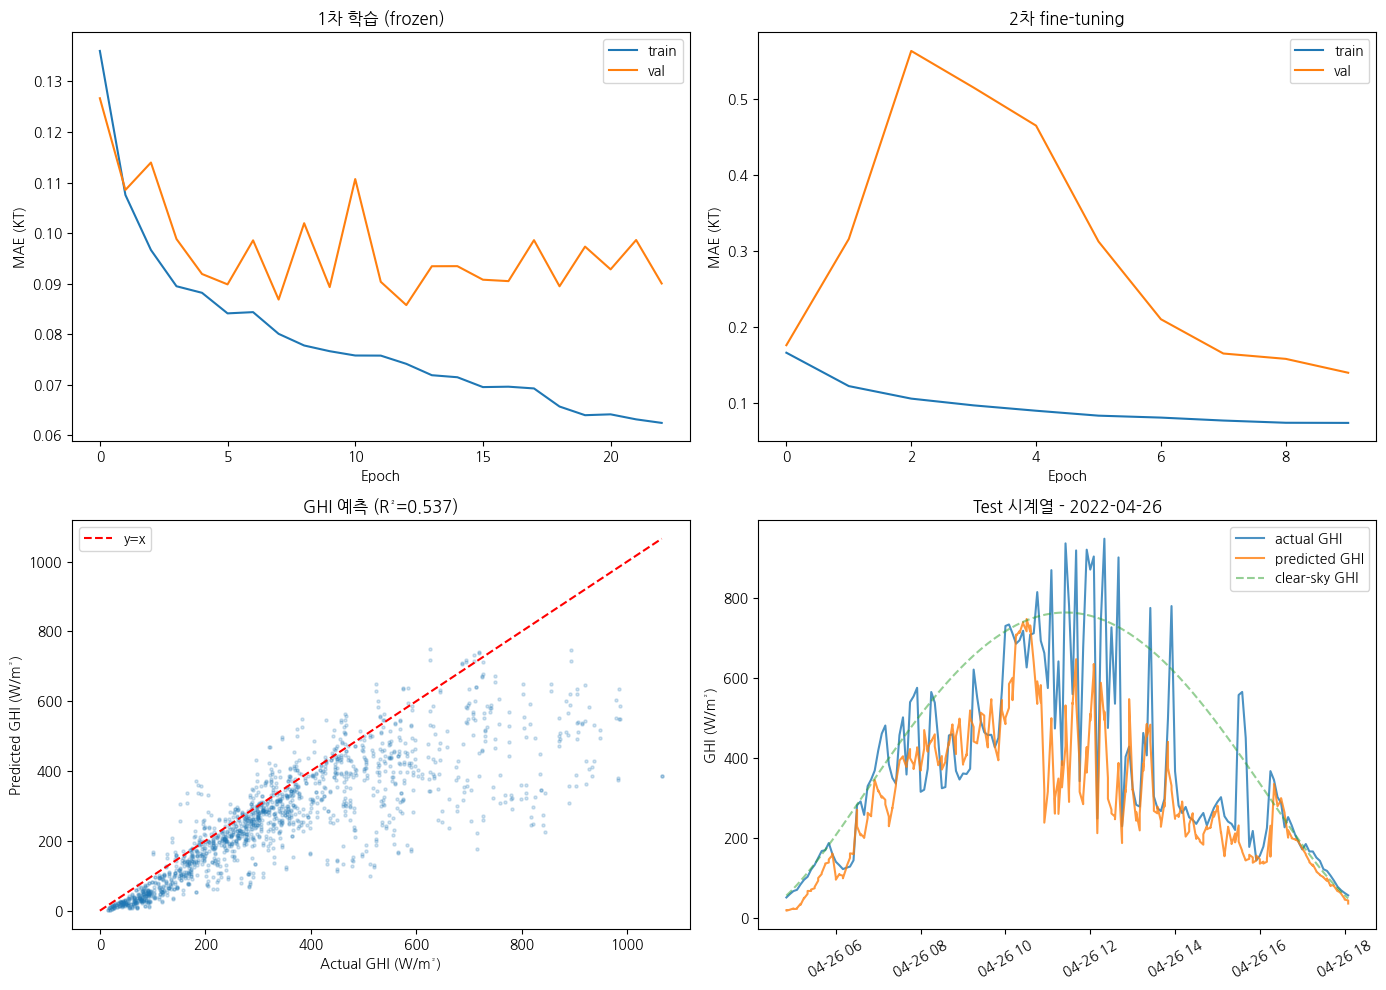

In [16]:
# 시각화: 학습 곡선 + 예측 vs 실제 + 하루치 시계열
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 학습 곡선 (1차)
axes[0,0].plot(history.history['loss'], label='train')
axes[0,0].plot(history.history['val_loss'], label='val')
axes[0,0].set_title('1차 학습 (frozen)')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('MAE (KT)'); axes[0,0].legend()

# 학습 곡선 (2차)
axes[0,1].plot(history_ft.history['loss'], label='train')
axes[0,1].plot(history_ft.history['val_loss'], label='val')
axes[0,1].set_title('2차 fine-tuning')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('MAE (KT)'); axes[0,1].legend()

# 예측 vs 실제 (GHI)
axes[1,0].scatter(ghi_true, ghi_pred, alpha=0.2, s=5)
lim = max(ghi_true.max(), ghi_pred.max())
axes[1,0].plot([0, lim], [0, lim], 'r--', label='y=x')
axes[1,0].set_xlabel('Actual GHI (W/m²)')
axes[1,0].set_ylabel('Predicted GHI (W/m²)')
axes[1,0].set_title(f'GHI 예측 (R²={r2:.3f})')
axes[1,0].legend()

# 하루치 시계열 (test set 첫날)
test_dates_sorted = sorted(set([t.date() for t in ts_test]))
target_date = test_dates_sorted[0]
day_mask = np.array([t.date() == target_date for t in ts_test])
ts_day = ts_test[day_mask]
axes[1,1].plot(ts_day, ghi_true[day_mask], label='actual GHI', alpha=0.8)
axes[1,1].plot(ts_day, ghi_pred[day_mask], label='predicted GHI', alpha=0.8)
axes[1,1].plot(ts_day, cghi_test[day_mask], '--', label='clear-sky GHI', alpha=0.5)
axes[1,1].set_title(f'Test 시계열 - {target_date}')
axes[1,1].set_ylabel('GHI (W/m²)')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('result.png', dpi=120)
plt.show()

## 9. 모델 저장 (라즈베리파이 배포용 TFLite + scaler)

In [18]:
import pickle

# TFLite 변환
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('kt_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'TFLite 크기: {len(tflite_model)/1024/1024:.2f} MB')

# scaler 저장
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 메타 정보
meta = {
    'img_size': IMG_SIZE,
    'target': 'KT (clear-sky index)',
    'tabular_inputs': ['SZA'],
    'output_range': [0, 1.5],
    'inference': 'GHI = KT × cGHI (cGHI는 pvlib 등으로 계산)',
}
with open('meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

from google.colab import files
files.download('kt_model.tflite')
files.download('scaler.pkl')
files.download('meta.pkl')
print('다운로드 완료')

Saved artifact at '/tmp/tmpfii2yu4n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='image'), TensorSpec(shape=(None, 1), dtype=tf.float32, name='tabular')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134917870161168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870162320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870162704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870161936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870160976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870162512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870162896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870163664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870163280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134917870160208: Tenso

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드 완료


## 10. 추론 예시 (cGHI는 pvlib로 계산)

추론 시 cGHI를 위경도/시각으로 계산해야 함. pvlib 쓰면 한 줄이다.

**OLCLO 좌표**: 약 53.13°N, 8.20°E (Oldenburg)

In [19]:
!pip install -q pvlib

import pvlib
from datetime import datetime

def compute_sza_cghi(dt_utc, lat, lon, altitude=10):
    """주어진 시각/위치에서 SZA와 clear-sky GHI 계산"""
    times = pd.DatetimeIndex([dt_utc]).tz_localize('UTC')
    loc = pvlib.location.Location(lat, lon, altitude=altitude)
    sp = loc.get_solarposition(times)
    cs = loc.get_clearsky(times, model='ineichen')
    return float(sp['zenith'].iloc[0]), float(cs['ghi'].iloc[0])

# 예: OLCLO 위치, 2022-04-15 12:00 UTC
sza, cghi = compute_sza_cghi(datetime(2022, 4, 15, 12, 0), lat=53.13, lon=8.20)
print(f'SZA={sza:.2f}°, cGHI={cghi:.1f} W/m²')

# 추론 함수
interpreter = tf.lite.Interpreter(model_path='kt_model.tflite')
interpreter.allocate_tensors()
in_details = interpreter.get_input_details()
out_details = interpreter.get_output_details()

def predict_ghi(img_array_rgb, dt_utc, lat=53.13, lon=8.20):
    """이미지 (H,W,3 RGB uint8 array) + 시각/위치 → GHI 예측"""
    sza, cghi = compute_sza_cghi(dt_utc, lat, lon)
    img = preprocess_image(img_array_rgb)[np.newaxis, ...].astype(np.float32)
    tab = scaler.transform([[sza]]).astype(np.float32)
    for inp in in_details:
        if 'image' in inp['name']:
            interpreter.set_tensor(inp['index'], img)
        elif 'tabular' in inp['name']:
            interpreter.set_tensor(inp['index'], tab)
    interpreter.invoke()
    kt_pred = float(interpreter.get_tensor(out_details[0]['index'])[0][0])
    return kt_pred * cghi, kt_pred, cghi, sza

print('\n추론 함수 준비 완료. predict_ghi(img, datetime, lat, lon) 호출.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 40.4 MB/s eta 0:00:00
SZA=43.77°, cGHI=707.3 W/m²

추론 함수 준비 완료. predict_ghi(img, datetime, lat, lon) 호출.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
